In [1]:
import sys
print(sys.executable)

/Users/dewna/Desktop/Research Project - Dewna/R26-IT-003/venv/bin/python


In [2]:
import pandas as pd

file_path = "../dataset/bird_radar_data_20211008_20211014/2021-10-14-21-58-47tracks.txt"

df = pd.read_csv(file_path, sep="\t")

df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc5 in position 5: invalid continuation byte

In [3]:
import pandas as pd

file_path = "../dataset/bird_radar_data_20211008_20211014/2021-10-14-21-58-47tracks.txt"

df = pd.read_csv(file_path, sep="\t", encoding="gbk")

df.head()

,帧头,批号,航迹得分,方位角,俯仰角,距离,航速,航向,目标速度方向,信噪比,...,目标威胁程度,预警时间,年,月,日,电脑时,电脑分,电脑秒,修正后时间（秒）,Unnamed: 23
0,3.428145e+09,15849.0,4.0,259.708634,14.776229,2194.239934,7.443760,233.163685,1.0,20.374705,...,1.0,3000.000000,2021.0,10.0,14.0,21.0,58.0,51.382,79131.382,NaN
1,3.428145e+09,15838.0,5.0,282.036012,16.162779,242.429790,1.470749,143.432445,0.0,17.360945,...,2.0,330.965093,2021.0,10.0,14.0,21.0,58.0,51.560,79131.560,NaN
2,3.428145e+09,15845.0,1.0,273.940199,20.044652,159.790771,3.330940,107.030712,1.0,15.289246,...,1.0,3000.000000,2021.0,10.0,14.0,21.0,58.0,51.705,79131.705,NaN
3,3.428145e+09,15842.0,3.0,285.329536,9.000436,236.693176,0.792747,352.223020,0.0,26.507787,...,3.0,178.848869,2021.0,10.0,14.0,21.0,58.0,51.902,79131.902,NaN
4,3.428145e+09,15852.0,1.0,291.504309,13.389116,2945.229663,11.991697,280.431895,1.0,18.683281,...,1.0,3000.000000,2021.0,10.0,14.0,21.0,58.0,52.034,79132.034,NaN


In [4]:
df.columns

Index(['帧头', '批号', '航迹得分', '方位角', '俯仰角', '距离', '航速', '航向', '目标速度方向', '信噪比',
       '纬度', '经度', '高度', '目标分类标志', '目标威胁程度', '预警时间', '年', '月', '日', '电脑时',
       '电脑分', '电脑秒', '修正后时间（秒）', 'Unnamed: 23'],
      dtype='str')

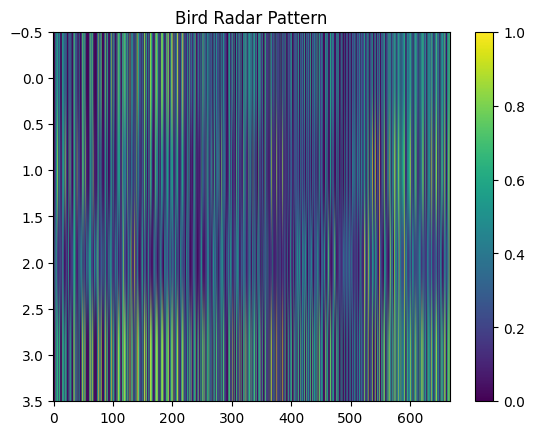

In [5]:
import matplotlib.pyplot as plt

# select features
features = df[["距离", "航速", "信噪比", "高度"]]

# normalize (important)
features = (features - features.min()) / (features.max() - features.min())

# convert to image
plt.imshow(features.T, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Bird Radar Pattern")
plt.show()

In [6]:
import os

save_path = "../dataset/train/bird"
os.makedirs(save_path, exist_ok=True)

plt.imshow(features.T, aspect='auto', cmap='viridis')
plt.axis("off")

plt.savefig(f"{save_path}/bird_1.png", bbox_inches='tight', pad_inches=0)
plt.close()


In [7]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

input_folder = "../dataset/bird_radar_data_20211008_20211014"
output_folder = "../dataset/train/bird"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(input_folder + "/*.txt")

image_count = 0
window_size = 300   # rows per image

for file in files:
    print("Processing:", file)
    
    df = pd.read_csv(file, sep="\t", encoding="gbk")
    
    features = df[["距离", "航速", "信噪比", "高度"]]
    features = features.dropna()
    
    for start in range(0, len(features), window_size):
        chunk = features.iloc[start:start + window_size]
        
        if len(chunk) < window_size:
            continue
        
        chunk = (chunk - chunk.min()) / (chunk.max() - chunk.min())
        
        plt.figure(figsize=(4, 4))
        plt.imshow(chunk.T, aspect="auto", cmap="viridis")
        plt.axis("off")
        
        save_file = f"{output_folder}/bird_{image_count}.png"
        plt.savefig(save_file, bbox_inches="tight", pad_inches=0)
        plt.close()
        
        image_count += 1

print("Generated bird radar images:", image_count)

Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-08-11-18-28tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-08-13-49-25tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-08-09-57-07tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-10-21-52-48tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-08-10-10-51tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-14-21-23-10tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-13-14-41-35tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-14-21-58-47tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-14-09-04-21tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-13-19-23-56tracks.txt
Processing: ../dataset/bird_radar_data_20211008_20211014/2021-10-13-09-21-37tracks.txt
Processing: ../dataset/bird_radar_data_2021

In [8]:
import os

train_path = "../dataset/train"

for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

bird 27371
ship 4718


In [13]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset

class BalancedRadarDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_per_class=4718):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {"bird": 0, "ship": 1}

        for class_name in ["bird", "ship"]:
            class_path = os.path.join(root_dir, class_name)
            images = os.listdir(class_path)

            images = [img for img in images if img.lower().endswith((".png", ".jpg", ".jpeg"))]
            random.shuffle(images)
            images = images[:max_per_class]

            for img in images:
                self.samples.append((os.path.join(class_path, img), self.class_to_idx[class_name]))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
import torch
print(torch.__version__)

2.11.0


In [11]:
from torch.utils.data import Dataset

In [15]:
from torchvision import transforms
from torch.utils.data import DataLoader

# image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# create dataset
dataset = BalancedRadarDataset(
    root_dir="../dataset/train",
    transform=transform,
    max_per_class=4718
)

# create dataloader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Total samples:", len(dataset))

Total samples: 9435


In [14]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset

class BalancedRadarDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_per_class=4718):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {"bird": 0, "ship": 1}

        for class_name in ["bird", "ship"]:
            class_path = os.path.join(root_dir, class_name)
            images = os.listdir(class_path)

            images = [img for img in images if img.lower().endswith((".png", ".jpg", ".jpeg"))]
            random.shuffle(images)
            images = images[:max_per_class]

            for img in images:
                self.samples.append((os.path.join(class_path, img), self.class_to_idx[class_name]))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RadarCNN(nn.Module):
    def __init__(self):
        super(RadarCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: bird, ship

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = RadarCNN()
print(model)

RadarCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [17]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 4.6329
Epoch 2, Loss: 0.0022
Epoch 3, Loss: 0.0009
Epoch 4, Loss: 0.0003
Epoch 5, Loss: 0.0002


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RadarCNN(nn.Module):
    def __init__(self):
        super(RadarCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [2]:
model = RadarCNN()
model.load_state_dict(torch.load("../models/radar_cnn_bird_ship.pth"))
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [3]:
import os

test_ship_path = "../dataset/test/ship"

print("Test ship images:", len(os.listdir(test_ship_path)))

Test ship images: 673


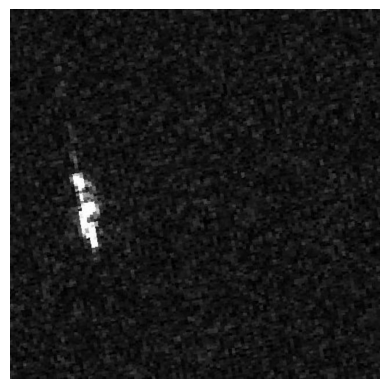

Prediction: ship


In [4]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

class_names = ["bird", "ship"]

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# 🔥 use TEST image
image_path = "../dataset/test/ship/000003_jpg.rf.d35f1b3e7a2f971d5edb6bd95bdb0af4.jpg"

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)

print("Prediction:", class_names[predicted.item()])

In [5]:
import os
from PIL import Image
import torch

test_dir = "../dataset/test/ship"

correct = 0
total = 0

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

    # label = 1 (ship)
    if predicted.item() == 1:
        correct += 1

    total += 1

accuracy = 100 * correct / total
print(f"Ship Test Accuracy: {accuracy:.2f}%")

UnidentifiedImageError: cannot identify image file '../dataset/test/ship/_annotations.coco.json'

In [6]:
import os
from PIL import Image
import torch

test_dir = "../dataset/test/ship"

correct = 0
total = 0

# ✅ allowed image formats
valid_extensions = (".jpg", ".jpeg", ".png")

for img_name in os.listdir(test_dir):

    # 🔥 skip non-image files
    if not img_name.lower().endswith(valid_extensions):
        continue

    img_path = os.path.join(test_dir, img_name)

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

    if predicted.item() == 1:  # ship
        correct += 1

    total += 1

accuracy = 100 * correct / total
print(f"Ship Test Accuracy: {accuracy:.2f}%")

Ship Test Accuracy: 100.00%


In [7]:
test_dir = "../dataset/train/bird"

correct = 0
total = 0

valid_extensions = (".jpg", ".jpeg", ".png")

for img_name in os.listdir(test_dir):
    if not img_name.lower().endswith(valid_extensions):
        continue

    img_path = os.path.join(test_dir, img_name)

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

    if predicted.item() == 0:  # bird
        correct += 1

    total += 1

accuracy = 100 * correct / total
print(f"Bird Accuracy: {accuracy:.2f}%")

Bird Accuracy: 100.00%


In [5]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

# test both classes
test_dirs = {
    0: "../dataset/train/bird",   # bird
    1: "../dataset/test/ship"     # ship
}

valid_extensions = (".jpg", ".jpeg", ".png")

for label, folder in test_dirs.items():
    for img_name in os.listdir(folder):

        if not img_name.lower().endswith(valid_extensions):
            continue

        img_path = os.path.join(folder, img_name)

        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)

        y_true.append(label)
        y_pred.append(predicted.item())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

NameError: name 'model' is not defined

In [2]:
import os
from PIL import Image
import torch
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

test_dirs = {
    0: "../dataset/train/bird",   # bird
    1: "../dataset/test/ship"     # ship
}

valid_extensions = (".jpg", ".jpeg", ".png")

for label, folder in test_dirs.items():
    for img_name in os.listdir(folder):

        if not img_name.lower().endswith(valid_extensions):
            continue

        img_path = os.path.join(folder, img_name)

        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)

        y_true.append(label)
        y_pred.append(predicted.item())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

NameError: name 'transform' is not defined

In [3]:
import os
from PIL import Image
import torch
from sklearn.metrics import confusion_matrix
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import confusion_matrix
from torchvision import transforms

In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [3]:
class RadarCNN(nn.Module):
    def __init__(self):
        super(RadarCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
model = RadarCNN()
model.load_state_dict(torch.load("../models/radar_cnn_bird_ship.pth"))
model.eval()

print("Model loaded")

Model loaded


In [5]:
y_true = []
y_pred = []

test_dirs = {
    0: "../dataset/train/bird",   # bird
    1: "../dataset/test/ship"     # ship
}

valid_extensions = (".jpg", ".jpeg", ".png")

for label, folder in test_dirs.items():
    for img_name in os.listdir(folder):

        if not img_name.lower().endswith(valid_extensions):
            continue

        img_path = os.path.join(folder, img_name)

        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)

        y_true.append(label)
        y_pred.append(predicted.item())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[27370     0]
 [    0   672]]


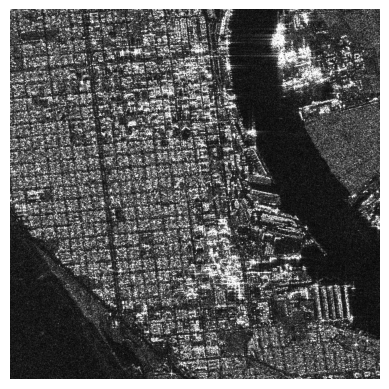

Prediction: ship
Confidence: 100.0 %


In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

image_path = "../dataset/test/custom/P0001_0_800_7200_8000dew.jpg"

class_names = ["bird", "ship"]

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

print("Prediction:", class_names[predicted.item()])
print("Confidence:", round(confidence.item() * 100, 2), "%")

In [7]:
import os
import random
from PIL import Image

source_dir = "../dataset/train/ship"
save_dir = "../dataset/train/unknown"

os.makedirs(save_dir, exist_ok=True)

count = 0

for img_name in os.listdir(source_dir):

    if not img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(source_dir, img_name)
    image = Image.open(img_path).convert("RGB")

    width, height = image.size

    # create 5 random crops per image
    for i in range(5):
        crop_size = 128

        if width < crop_size or height < crop_size:
            continue

        x = random.randint(0, width - crop_size)
        y = random.randint(0, height - crop_size)

        crop = image.crop((x, y, x + crop_size, y + crop_size))

        save_path = os.path.join(save_dir, f"unknown_{count}.jpg")
        crop.save(save_path)

        count += 1

print("Generated unknown images:", count)

Generated unknown images: 23585


In [8]:
import os, random
from PIL import Image
from torch.utils.data import Dataset

class BalancedRadarDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_per_class=4718):
        self.transform = transform
        self.samples = []
        self.class_to_idx = {
            "bird": 0,
            "ship": 1,
            "unknown": 2
        }

        for class_name in ["bird", "ship", "unknown"]:
            class_path = os.path.join(root_dir, class_name)
            images = [img for img in os.listdir(class_path)
                      if img.lower().endswith((".png", ".jpg", ".jpeg"))]

            random.shuffle(images)
            images = images[:max_per_class]

            for img in images:
                self.samples.append((os.path.join(class_path, img), self.class_to_idx[class_name]))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = BalancedRadarDataset(
    root_dir="../dataset/train",
    transform=transform,
    max_per_class=4718
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Total samples:", len(dataset))

Total samples: 14153


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RadarCNN3Class(nn.Module):
    def __init__(self):
        super(RadarCNN3Class, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 3)  # bird, ship, unknown

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = RadarCNN3Class()
print(model)

RadarCNN3Class(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [11]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 106.4602
Epoch 2, Loss: 35.7751
Epoch 3, Loss: 24.9761
Epoch 4, Loss: 16.1547
Epoch 5, Loss: 12.8261


In [12]:
torch.save(model.state_dict(), "../models/radar_cnn_3class.pth")
print("3-class model saved")

3-class model saved


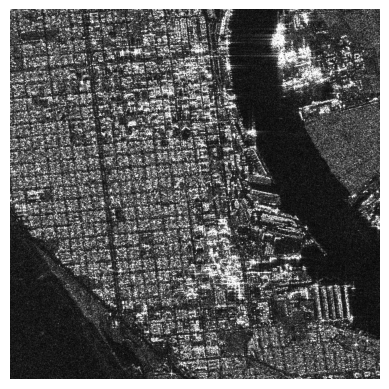

Prediction: ship
Confidence: 90.84 %


In [13]:
class_names = ["bird", "ship", "unknown"]

image_path = "../dataset/test/custom/P0001_0_800_7200_8000dew.jpg"

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

print("Prediction:", class_names[predicted.item()])
print("Confidence:", round(confidence.item() * 100, 2), "%")

In [15]:
from PIL import Image
import os
import random

source_image = "../dataset/test/custom/P0001_0_800_7200_8000dew.jpg"
save_dir = "../dataset/train/unknown"

os.makedirs(save_dir, exist_ok=True)

image = Image.open(source_image).convert("RGB")
width, height = image.size

count_start = len(os.listdir(save_dir))
crop_size = 128

for i in range(500):
    x = random.randint(0, width - crop_size)
    y = random.randint(0, height - crop_size)

    crop = image.crop((x, y, x + crop_size, y + crop_size))
    crop.save(os.path.join(save_dir, f"custom_unknown_{count_start+i}.jpg"))

print("Added 500 custom unknown patches")

Added 500 custom unknown patches


In [20]:
model = RadarCNN3Class()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

KeyboardInterrupt: 

In [17]:
torch.save(model.state_dict(), "../models/radar_cnn_3class.pth")
print("Updated 3-class model saved")

Updated 3-class model saved


In [22]:
model = RadarCNN3Class()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 126.5858
Epoch 2, Loss: 46.6860
Epoch 3, Loss: 26.6616
Epoch 4, Loss: 18.7998
Epoch 5, Loss: 11.6659


In [23]:
torch.save(model.state_dict(), "../models/radar_cnn_3class.pth")
print("Updated 3-class model saved")

Updated 3-class model saved


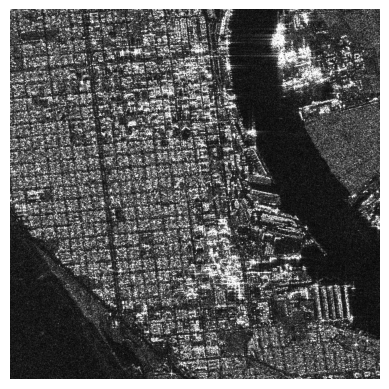

Prediction: ship
Confidence: 99.89 %


In [24]:
class_names = ["bird", "ship", "unknown"]

image_path = "../dataset/test/custom/P0001_0_800_7200_8000dew.jpg"

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

print("Prediction:", class_names[predicted.item()])
print("Confidence:", round(confidence.item() * 100, 2), "%")

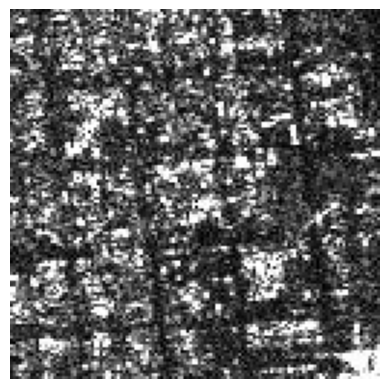

Prediction: unknown
Confidence: 99.99 %
All probabilities: [[3.91801598e-25 1.01699734e-04 9.99898314e-01]]


In [25]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

class_names = ["bird", "ship", "unknown"]

image_path = "../dataset/test/custom/P0001_0_800_7200_8000dew.jpg"

image = Image.open(image_path).convert("RGB")

# crop center area
w, h = image.size
crop_size = 128
left = (w - crop_size) // 2
top = (h - crop_size) // 2
crop = image.crop((left, top, left + crop_size, top + crop_size))

plt.imshow(crop)
plt.axis("off")
plt.show()

input_tensor = transform(crop).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

print("Prediction:", class_names[predicted.item()])
print("Confidence:", round(confidence.item() * 100, 2), "%")
print("All probabilities:", probabilities.cpu().numpy())